# 09.3 · FAST, scale and detector tradeoffs

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain fast, scale and detector tradeoffs using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md), [05 · Image Processing](../../05-image-processing/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

A feature is a location with a pattern that can be found again. A uniform wall gives no precise location; a corner constrains movement in two directions. Feature detection chooses interesting points, while feature description records a neighborhood for later comparison.

## 2. Intuition

FAST compares a ring of pixels around a candidate to its center and searches for a contiguous brighter or darker arc. It is efficient but not inherently scale invariant. SIFT adds scale-space extrema and orientation; ORB combines oriented FAST with a binary descriptor. Detection repeatability and descriptor distinctiveness are different properties.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 9
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
R=\det(M)-k\,\operatorname{trace}(M)^2
$$

M is the 2×2 sum of local gradient outer products, R the Harris response and k a sensitivity parameter. For eigenvalues 4 and 3, det=12 and trace=7; with k=0.04, R=10.04.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
M = np.diag([4.0, 3.0])
k = 0.04
response = np.linalg.det(M) - k * np.trace(M) ** 2
assert np.isclose(response, 10.04)
print(response)

10.04


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The reference computes Sobel gradients, smooths their products and forms the response. The library comparison applies detector-specific selection, so point sets need not be identical.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def features(lesson, seed, amount):
    image = picture(seed)
    grayscale = n.gray(image).astype(np.uint8)
    response = n.harris(grayscale)
    view = image.copy()
    if lesson == 0:
        threshold = response.max() * 0.1 * amount
        peaks = (response == cv2.dilate(response, np.ones((5, 5)))) & (response > threshold)
        view[peaks] = [255, 255, 255]
        count = int(peaks.sum())
    elif lesson == 1:
        points = cv2.goodFeaturesToTrack(grayscale, 50, 0.02 * amount, 5)
        count = 0 if points is None else len(points)
        for point in [] if points is None else points:
            cv2.circle(view, tuple(point.ravel().astype(int)), 2, (255, 255, 255), 1)
    else:
        points = cv2.FastFeatureDetector_create(threshold=max(2, int(12 * amount))).detect(
            grayscale
        )
        view = cv2.drawKeypoints(view, points, None, color=(255, 255, 255))
        count = len(points)
    return Result(
        "09 · Repeatable corners and detector responses",
        {"Image": image, "Harris response": response, "Detected locations": view},
        metrics={"feature_count": count},
    )

{
  "feature_count": 15
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import harris

display(Code(inspect.getsource(harris), language="python"))

def harris(image, k=0.04, window=5):
    """Corner response det(M)-k*trace(M)^2 from local gradient products."""
    gx, gy, _ = sobel(image)
    average = np.ones((window, window)) / window**2
    a, b, c = (correlate(v, average) for v in (gx * gx, gx * gy, gy * gy))
    return a * c - b * b - k * (a + c) ** 2

## 8. Experiment

Rotate and blur a checkerboard. Count repeatable detections after transforming coordinates back, rather than comparing only raw detection counts.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "feature_count": 15
  },
  "second_seed": {
    "feature_count": 17
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

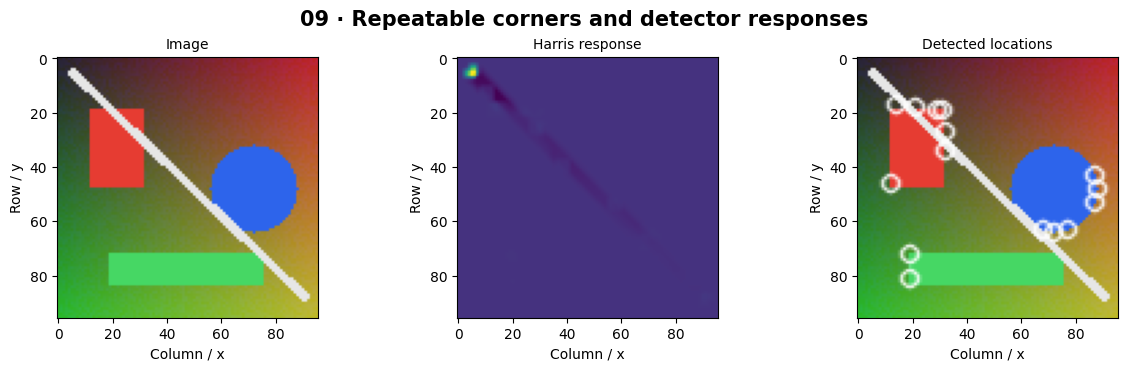

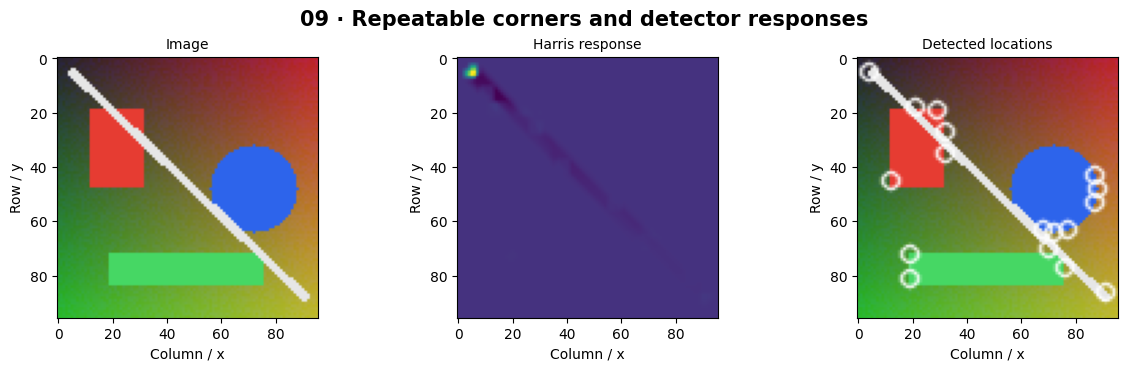

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Corner Explorer**. Find repeatable image locations and explain detector tradeoffs. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A high feature count is not proof of useful coverage. Border padding and threshold units influence the response.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Rotate and blur a checkerboard. Count repeatable detections after transforming coordinates back, rather than comparing only raw detection counts.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a feature benchmark that measures repeatability under known rotations, scales and illumination changes.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

FAST compares a ring of pixels around a candidate to its center and searches for a contiguous brighter or darker arc. It is efficient but not inherently scale invariant. SIFT adds scale-space extrema and orientation; ORB combines oriented FAST with a binary descriptor. Detection repeatability and descriptor distinctiveness are different properties.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[10 · Feature Description and Matching](../../10-feature-description-and-matching/README.md)

[Primary reference](https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)